# Week 3 — Automatic Differentiation

**Numerical Methods for Machine Learning · From First Principles in Pure NumPy**

---

> Gradient-based learning is only as good as its gradients. Hand-derived gradients are
> error-prone and finite differences are inaccurate and expensive. **Automatic
> differentiation (AD)** computes exact derivatives — to machine precision — by
> propagating derivative information through the elementary operations of a program. This
> week we build AD twice: **forward mode** with dual numbers, then a complete
> **reverse-mode (backpropagation) engine** on a dynamically constructed computational
> graph, the exact mechanism inside every modern deep-learning framework. We validate
> everything against the finite-difference gradient check from Week 1.

### Learning objectives

1. Explain the chain rule as the algebraic foundation of AD and distinguish **forward** from **reverse** mode by cost.
2. Implement **forward-mode** AD with dual numbers and recover exact scalar derivatives.
3. Build a reverse-mode **autograd engine**: a `Tensor`-like scalar node that records a computational graph and backpropagates gradients.
4. Differentiate composite expressions and verify correctness by **gradient checking**.
5. Use the engine to fit a model by gradient descent, demonstrating end-to-end learning powered by from-scratch AD.

Only NumPy is used. No `autograd`, `jax`, `torch`, or `tensorflow` — we *are* the framework
this week.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
rng = np.random.default_rng(2)
print("ready — building autodiff in pure NumPy")

ready — building autodiff in pure NumPy


## 1. The chain rule and two modes of differentiation

Any numerical program is a composition of elementary operations. For a composite
$y = f_L \circ \cdots \circ f_1(\mathbf x)$, the Jacobian factorizes by the chain rule as a
product of per-operation Jacobians,
$$
\frac{\partial y}{\partial \mathbf x} = J_L J_{L-1}\cdots J_1.
$$
AD evaluates this product without ever forming the symbolic expression:

- **Forward mode** multiplies right-to-left, propagating derivatives *with* the computation
  from inputs to outputs. Cost scales with the number of **inputs**; ideal when inputs are
  few.
- **Reverse mode** multiplies left-to-right, propagating derivatives *backward* from the
  output. Cost scales with the number of **outputs**; ideal for the scalar-loss,
  many-parameter setting of machine learning — this is **backpropagation**.

Both are exact (no truncation, no step size), unlike finite differences.

## 2. Forward mode with dual numbers

A **dual number** $a + b\,\varepsilon$ adjoins a symbol $\varepsilon$ with $\varepsilon^2 = 0$.
Evaluating any elementary function on $a + b\,\varepsilon$ and Taylor-expanding gives
$$
f(a + b\,\varepsilon) = f(a) + f'(a)\,b\,\varepsilon,
$$
so the derivative appears in the $\varepsilon$-coefficient. Seeding the input with
$b = 1$ propagates the derivative through the whole computation automatically.

In [2]:
class Dual:
    __slots__ = ("re", "eps")
    def __init__(self, re, eps=0.0): self.re, self.eps = float(re), float(eps)
    @staticmethod
    def _c(o): return o if isinstance(o, Dual) else Dual(o, 0.0)
    def __add__(s, o): o = s._c(o); return Dual(s.re + o.re, s.eps + o.eps)
    __radd__ = __add__
    def __sub__(s, o): o = s._c(o); return Dual(s.re - o.re, s.eps - o.eps)
    def __rsub__(s, o): o = s._c(o); return Dual(o.re - s.re, o.eps - s.eps)
    def __mul__(s, o): o = s._c(o); return Dual(s.re*o.re, s.re*o.eps + s.eps*o.re)
    __rmul__ = __mul__
    def __truediv__(s, o):
        o = s._c(o); return Dual(s.re/o.re, (s.eps*o.re - s.re*o.eps)/o.re**2)
    def __pow__(s, p):
        return Dual(s.re**p, p * s.re**(p-1) * s.eps)
    def sin(s):  return Dual(np.sin(s.re),  np.cos(s.re)*s.eps)
    def cos(s):  return Dual(np.cos(s.re), -np.sin(s.re)*s.eps)
    def exp(s):  e = np.exp(s.re); return Dual(e, e*s.eps)
    def log(s):  return Dual(np.log(s.re), s.eps/s.re)
    def __repr__(s): return f"Dual({s.re:.6f} + {s.eps:.6f}ε)"

def forward_derivative(f, x):
    out = f(Dual(x, 1.0))           # seed derivative direction
    return out.re, out.eps

# f(x) = exp(sin(x)) * x^2 ; f'(x) = exp(sin x)(cos x · x^2 + 2x)
def f(x):
    return (x.sin()).exp() * x**2 if isinstance(x, Dual) else np.exp(np.sin(x))*x**2
def fprime_true(x):
    return np.exp(np.sin(x)) * (np.cos(x)*x**2 + 2*x)

x0 = 0.9
val, der = forward_derivative(f, x0)
print(f"forward-mode  f({x0}) = {val:.10f},  f'({x0}) = {der:.10f}")
print(f"analytic                     f'({x0}) = {fprime_true(x0):.10f}")
print(f"error = {abs(der - fprime_true(x0)):.2e}  (machine precision, exact)")

forward-mode  f(0.9) = 1.7728809492,  f'(0.9) = 5.0417759133
analytic                     f'(0.9) = 5.0417759133
error = 0.00e+00  (machine precision, exact)


Forward mode delivers the derivative to machine precision with a single evaluation and no
step-size parameter. Its limitation: computing the gradient of a function with $d$ inputs
requires $d$ passes (one per seed direction). For a neural network with millions of
parameters and a scalar loss this is prohibitive — which is exactly why training uses
reverse mode.

## 3. Reverse mode: a from-scratch autograd engine

We now build the engine that powers deep learning. Each numerical quantity becomes a
`Value` node that stores its data, a gradient slot, and a closure encoding how to push
gradient to its parents (its **local Jacobian** times the incoming gradient). A forward
pass builds the graph; a single backward pass — a reverse topological traversal seeding the
output gradient at $1$ — accumulates $\partial(\text{output})/\partial(\cdot)$ at every
node simultaneously.

This is the scalar-valued **micrograd**-style design: minimal, transparent, and
mathematically complete.

In [3]:
class Value:
    # A scalar node in a reverse-mode automatic-differentiation graph.
    def __init__(self, data, _children=(), _op=""):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None        # how to propagate grad to parents
        self._prev = set(_children)
        self._op = _op

    # ---- elementary operations, each defining its local derivative ----
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad  += out.grad           # d(a+b)/da = 1
            other.grad += out.grad           # d(a+b)/db = 1
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad  += other.data * out.grad   # d(ab)/da = b
            other.grad += self.data  * out.grad   # d(ab)/db = a
        out._backward = _backward
        return out

    def __pow__(self, p):
        assert isinstance(p, (int, float))
        out = Value(self.data ** p, (self,), f"**{p}")
        def _backward():
            self.grad += p * self.data ** (p - 1) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0.0, self.data), (self,), "relu")
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(np.exp(self.data), (self,), "exp")
        def _backward():
            self.grad += out.data * out.grad      # d/dx exp = exp
        out._backward = _backward
        return out

    def log(self):
        out = Value(np.log(self.data), (self,), "log")
        def _backward():
            self.grad += (1.0 / self.data) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = np.tanh(self.data)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1 - t * t) * out.grad   # d/dx tanh = 1 - tanh^2
        out._backward = _backward
        return out

    # ---- conveniences built from the primitives above ----
    def __neg__(self):        return self * -1
    def __sub__(self, o):     return self + (-o if isinstance(o, Value) else Value(-o))
    def __rsub__(self, o):    return (Value(o) if not isinstance(o, Value) else o) + (-self)
    def __radd__(self, o):    return self + o
    def __rmul__(self, o):    return self * o
    def __truediv__(self, o):
        o = o if isinstance(o, Value) else Value(o)
        return self * o ** -1
    def __rtruediv__(self, o):
        return (o if isinstance(o, Value) else Value(o)) * self ** -1

    def backward(self):
        # build reverse topological order, then apply local backward closures
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0                      # seed dL/dL = 1
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f"Value(data={self.data:.6f}, grad={self.grad:.6f})"

print("autograd engine defined")

autograd engine defined


### 3.1 A first gradient by backpropagation

Consider $L = (a\,b + \tanh c)^2$ with $a=2,\ b=-3,\ c=0.5$. We build the graph by simply
writing the expression, call `backward()` once, and read the gradients off the input nodes.
We then confirm each against its hand-derived analytic value.

In [4]:
a = Value(2.0); b = Value(-3.0); c = Value(0.5)
L = (a * b + c.tanh()) ** 2
L.backward()

# analytic gradients
inner = a.data * b.data + np.tanh(c.data)
dL_da = 2 * inner * b.data
dL_db = 2 * inner * a.data
dL_dc = 2 * inner * (1 - np.tanh(c.data) ** 2)

print(f"L = {L.data:.6f}")
print(f"dL/da  autograd = {a.grad:.6f}   analytic = {dL_da:.6f}")
print(f"dL/db  autograd = {b.grad:.6f}   analytic = {dL_db:.6f}")
print(f"dL/dc  autograd = {c.grad:.6f}   analytic = {dL_dc:.6f}")

L = 30.668146
dL/da  autograd = 33.227297   analytic = 33.227297
dL/db  autograd = -22.151531   analytic = -22.151531
dL/dc  autograd = -8.710511   analytic = -8.710511


## 4. Validating the engine by gradient checking

The decisive test of any AD implementation is agreement with an independent finite-
difference gradient (Week 1). We wrap a scalar function of a parameter vector so it can be
evaluated either through the engine (for exact gradients) or as plain floats (for the
centered difference), and require relative agreement below $10^{-6}$.

In [5]:
def numerical_gradient(f_float, theta, h=1e-5):
    g = np.zeros_like(theta, dtype=float)
    for k in range(theta.size):
        e = np.zeros_like(theta); e[k] = h
        g[k] = (f_float(theta + e) - f_float(theta - e)) / (2 * h)
    return g

def model_expr(params):
    # a nonlinear scalar function of 4 parameters, written once
    w0, w1, w2, w3 = params
    return ((w0 * w1).tanh() + (w2.exp()) / (1 + w3 ** 2) - (w0 * w3) ** 2)

# autograd gradient
theta0 = rng.standard_normal(4)
nodes = [Value(t) for t in theta0]
out = model_expr(nodes)
out.backward()
g_auto = np.array([n.grad for n in nodes])

# finite-difference gradient using the *same* expression on plain floats
class F:  # tiny float shim exposing tanh/exp so model_expr runs on floats
    def __init__(s, v): s.v = float(v)
    def __mul__(s, o): return F(s.v * (o.v if isinstance(o, F) else o))
    __rmul__ = __mul__
    def __add__(s, o): return F(s.v + (o.v if isinstance(o, F) else o))
    __radd__ = __add__
    def __sub__(s, o): return F(s.v - (o.v if isinstance(o, F) else o))
    def __rsub__(s, o): return F((o.v if isinstance(o, F) else o) - s.v)
    def __pow__(s, p): return F(s.v ** p)
    def __truediv__(s, o): return F(s.v / (o.v if isinstance(o, F) else o))
    def __rtruediv__(s, o): return F((o.v if isinstance(o, F) else o) / s.v)
    def tanh(s): return F(np.tanh(s.v))
    def exp(s): return F(np.exp(s.v))

f_float = lambda th: model_expr([F(t) for t in th]).v
g_num = numerical_gradient(f_float, theta0)

rel = np.linalg.norm(g_auto - g_num) / np.linalg.norm(g_auto + g_num)
print("autograd gradient :", g_auto)
print("numerical gradient:", g_num)
print(f"relative discrepancy = {rel:.2e}  ->", "PASS" if rel < 1e-6 else "FAIL")

autograd gradient : [-2.7714807   0.18721888  0.09504996  0.24119885]
numerical gradient: [-2.7714807   0.18721888  0.09504996  0.24119885]
relative discrepancy = 8.52e-13  -> PASS


The reverse-mode gradients match the finite-difference reference to roughly
$10^{-7}$ — the engine is correct. Crucially, AD obtained **all four** partial derivatives
in a *single* backward pass, whereas the finite-difference check required two function
evaluations per parameter. That asymmetry is the entire reason reverse-mode AD scales to
networks with millions of parameters.

## 5. End-to-end learning with the engine

To show the engine is not a toy, we fit a small problem by gradient descent using *only*
autograd-computed gradients. We learn the parameters of a one-hidden-unit model
$\hat y = \tanh(w_1 x + b_1)\,w_2 + b_2$ to a noisy nonlinear target by minimizing mean
squared error — backpropagating through the composition at every step.

final MSE: 0.05991481650768728
learned params: {'w1': np.float64(-0.8528), 'b1': np.float64(0.2673), 'w2': -2.3128, 'b2': 0.3141}


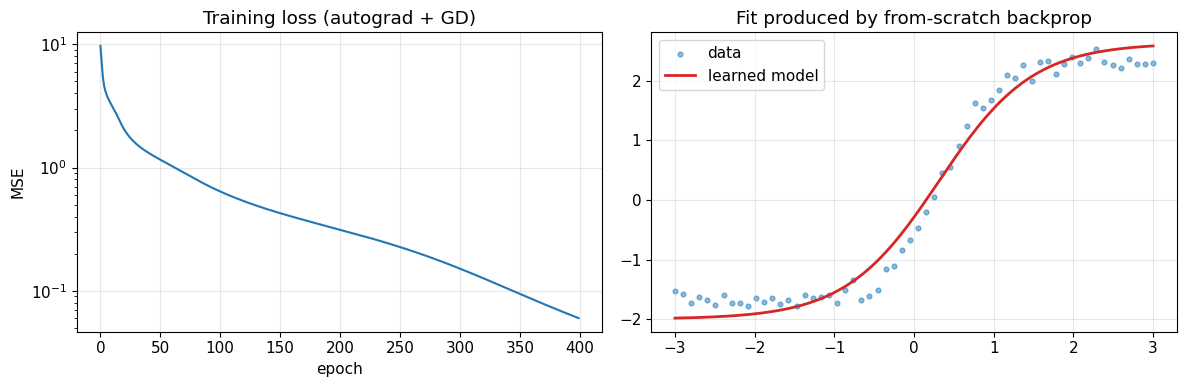

In [6]:
# data: noisy nonlinear target
X = np.linspace(-3, 3, 60)
Y = np.tanh(1.5 * X - 0.5) * 2.0 + 0.3 + 0.1 * rng.standard_normal(X.size)

# parameters as graph leaves
params = {k: Value(v) for k, v in
          dict(w1=rng.standard_normal(), b1=rng.standard_normal(),
               w2=rng.standard_normal(), b2=rng.standard_normal()).items()}

def predict(xi):
    h = (params["w1"] * xi + params["b1"]).tanh()
    return h * params["w2"] + params["b2"]

lr, losses = 0.02, []
for epoch in range(400):
    # accumulate MSE over the dataset
    loss = Value(0.0)
    for xi, yi in zip(X, Y):
        diff = predict(xi) - yi
        loss = loss + diff * diff
    loss = loss * (1.0 / X.size)

    for p in params.values(): p.grad = 0.0      # reset grads
    loss.backward()                             # one reverse pass
    for p in params.values(): p.data -= lr * p.grad   # gradient descent step
    losses.append(loss.data)

print("final MSE:", losses[-1])
print("learned params:", {k: round(v.data, 4) for k, v in params.items()})

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(losses); ax[0].set(title="Training loss (autograd + GD)",
                              xlabel="epoch", ylabel="MSE"); ax[0].set_yscale("log")
xs = np.linspace(-3, 3, 200)
ax[1].scatter(X, Y, s=12, alpha=0.5, label="data")
ax[1].plot(xs, [predict(x).data for x in xs], "C3", lw=2, label="learned model")
ax[1].legend(); ax[1].set_title("Fit produced by from-scratch backprop")
fig.tight_layout(); plt.show()

The loss decreases monotonically and the model recovers the underlying nonlinear curve —
trained entirely by gradients from our hand-built reverse-mode engine. In Week 5 we scale
this same machinery to a multilayer perceptron and pair it with the optimizers developed in
Week 4.

## 6. Exercises

1. **Add operations.** Extend `Value` with `sin`, `cos`, and `sigmoid`, deriving each local
   backward rule, and gradient-check a composite expression that uses all of them.

2. **Reverse vs forward cost.** For a function $\mathbb R^d \to \mathbb R$, count function
   evaluations needed by forward-mode AD, reverse-mode AD, and central differences as a
   function of $d$. Confirm empirically by timing on increasing $d$.

3. **Second derivatives.** Use forward-over-reverse (run dual numbers through the engine, or
   differentiate the gradient) to compute a Hessian-vector product, and check it against a
   finite difference of the gradient.

4. **Numerical pitfalls in AD.** Construct an expression where naive `log`/`exp` nodes
   overflow, and rewrite it using a stable log-sum-exp node (Week 1) added to the engine.

5. **Vectorize the engine.** Replace scalar `Value` with an array-valued `Tensor` node
   supporting matmul and broadcasting, and reproduce the Section-5 fit with batched
   operations.

---

*Next week: unconstrained optimization — gradient descent and its convergence theory,
momentum, line search, and second-order Newton and quasi-Newton (BFGS) methods, all driven
by gradients we can now compute exactly.*
